In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df_hidroclorofluorocarbonos = pd.read_csv("Dataset\Consumo de hidroclorofluorocarbonos.csv", sep=';')
df_des_provincia = pd.read_csv("Dataset\Emisiones anuales desagregadas por provincia_2010_2022.csv", sep=';')
df_anual = pd.read_csv("Dataset\Emisiones anuales_1990_2022.csv", sep=';')
df_total = pd.read_csv("Dataset\Emisiones_datos_totales_1990_2022.csv", sep=';')
df_sector = pd.read_csv("Dataset\emisiones_sector_1990_2022.csv", sep=';')
df_tipo_sector = pd.read_csv("Dataset\emisiones_sector_tipo_gas_1990_2022.csv", sep=';')
df_subsector = pd.read_csv("Dataset\emisiones_subsector_no_ipcc_1990_2022.csv", sep=';')
df_gas = pd.read_csv("Dataset\emisiones_tipo_gas_1990_2022_ic.csv", sep=';')


<>:1: SyntaxWarning: "\C" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\C"? A raw string is also an option.
<>:2: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:3: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:4: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:5: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:6: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\e"? A raw string is also an option.
<>:7: SyntaxWarning: "\e" is an invalid escape sequence. Such sequences will not w

Realizar busqueda de nulos en fluorados y eliminar duplicados de des_provincia
Trabajar con los datos de sector ,sector tipo, subsector y tipo de gas

In [28]:
df_hidroclorofluorocarbonos.info()

df_hidroclorofluorocarbonos.shape

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   año                     23 non-null     int64
 1   consumo_hcfc_toneladas  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


(23, 2)

In [55]:
df_des_provincia.info()

df_des_provincia.shape

<class 'pandas.DataFrame'>
RangeIndex: 43682 entries, 0 to 43681
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   aÃ±o                  43682 non-null  int64  
 1   provincia             43682 non-null  str    
 2   sector                43682 non-null  str    
 3   subsector             43682 non-null  str    
 4   tipo_de_gas           43682 non-null  str    
 5   valor_toneladas_gas   43682 non-null  float64
 6   valor_toneladas_co2e  43682 non-null  float64
dtypes: float64(2), int64(1), str(4)
memory usage: 2.3 MB


(43682, 7)

In [6]:
#Total de duplicados de df_des_provincia

columnas = [col for col in df_des_provincia.columns if col not in ['valor_toneladas_gas', 'valor_toneladas_co2e']]

df_limpio_provincia = df_des_provincia.drop_duplicates(subset=columnas, keep='first')

print(f"Filas originales: {len(df_des_provincia)}")
print(f"Filas después de limpiar: {len(df_limpio_provincia)}")

Filas originales: 43682
Filas después de limpiar: 7013


In [30]:
df_anual.info()

df_anual.shape

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   año       33 non-null     int64  
 1   unidad    33 non-null     str    
 2   cantidad  33 non-null     float64
dtypes: float64(1), int64(1), str(1)
memory usage: 924.0 bytes


(33, 3)

In [9]:
df_total.info()

df_total.shape

<class 'pandas.DataFrame'>
RangeIndex: 7778 entries, 0 to 7777
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   año                         7778 non-null   int64  
 1   sector                      7778 non-null   str    
 2   actividad                   7778 non-null   str    
 3   subactividad                7778 non-null   str    
 4   categoria                   7778 non-null   str    
 5   id_ipcc                     7778 non-null   str    
 6   tipo_de_gas                 7778 non-null   str    
 7   valor_en_toneladas_de_co2e  7778 non-null   float64
dtypes: float64(1), int64(1), str(6)
memory usage: 486.3 KB


(7778, 8)

In [10]:
#Total de duplicados de df_total

columna = [col for col in df_total.columns if col not in ['valor_en_toneladas_de_co2e']]

df_limpio_total = df_total.drop_duplicates(subset=columna, keep='first')

print(f"Filas originales: {len(df_total)}")
print(f"Filas después de limpiar: {len(df_limpio_total)}")

Filas originales: 7778
Filas después de limpiar: 7610


In [34]:
df_sector.info()

df_sector.shape

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 8 columns):
 #   Column                                                        Non-Null Count  Dtype  
---  ------                                                        --------------  -----  
 0   año                                                           33 non-null     int64  
 1   energia                                                       33 non-null     float64
 2   procesos_industriales_y_uso_de_productos                      33 non-null     float64
 3   agricultura_y_ganaderia                                       33 non-null     float64
 4   usos_de_la_tierra_cambios_de_uso_de_la_tierra_y_silvicultura  33 non-null     float64
 5   residuos                                                      33 non-null     float64
 6   total                                                         33 non-null     float64
 7   unidad_de_medida                                              33 non-null     str    

(33, 8)

In [35]:
df_tipo_sector.info()

df_tipo_sector.shape

<class 'pandas.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   año               165 non-null    int64  
 1   sector            165 non-null    str    
 2   unidad_de_medida  165 non-null    str    
 3   total             165 non-null    float64
 4   co2               165 non-null    float64
 5   ch4               165 non-null    float64
 6   n2o               165 non-null    float64
 7   otros_gei         165 non-null    float64
dtypes: float64(5), int64(1), str(2)
memory usage: 10.4 KB


(165, 8)

In [36]:
df_subsector.info()

df_subsector.shape

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 16 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   año                                     33 non-null     int64  
 1   agricultura                             33 non-null     float64
 2   aguas_residuales                        33 non-null     float64
 3   cambio_de_uso_de_suelos_y_silvicultura  33 non-null     float64
 4   combustibles_industrias                 33 non-null     float64
 5   combustibles_otros_sectores             33 non-null     float64
 6   combustibles_residencial                33 non-null     float64
 7   emisiones_fugitivas                     33 non-null     float64
 8   fabricacion_de_combustibles             33 non-null     float64
 9   ganaderia                               33 non-null     float64
 10  generacion_de_electricidad              33 non-null     float64
 11  proces

(33, 16)

In [49]:
df_gas.info()

df_gas.shape

<class 'pandas.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   año               33 non-null     str    
 1   total             33 non-null     float64
 2   unidad_de_medida  33 non-null     str    
 3   co2               33 non-null     float64
 4   ch4               33 non-null     float64
 5   n2o               33 non-null     float64
 6   otros_gei         33 non-null     float64
dtypes: float64(5), str(2)
memory usage: 1.9 KB


(33, 7)

In [48]:
#Cambio de tipo de dato de año a str

df_hidroclorofluorocarbonos["año"] = df_hidroclorofluorocarbonos["año"].astype(str)

df_limpio_provincia["año"] = df_limpio_provincia["año"].astype(str)

df_anual["año"] = df_anual["año"].astype(str)

df_limpio_total["año"] = df_limpio_total["año"].astype(str)

df_fluorados["año"] = df_fluorados["año"].astype(str)

df_pib["año"] = df_pib["año"].astype(str)

df_sector["año"] = df_sector["año"].astype(str)

df_tipo_sector["año"] = df_tipo_sector["año"].astype(str)

df_subsector["año"] = df_subsector["año"].astype(str)

df_gas["año"] = df_gas["año"].astype(str)

In [64]:
#Creacion de copia de los limpios de des_provincia y total para trabajar con ellos sin modificar los originales


df_des_provincia = pd.read_csv("Dataset\Emisiones anuales desagregadas por provincia_2010_2022.csv", sep=";")
print(f" Archivo original cargado. Filas iniciales: {len(df_des_provincia)}")

df_des_provincia["año"] = df_des_provincia["año"].astype(str)

df_limpio_provincia = df_des_provincia.copy()

columnas = [col for col in df_des_provincia.columns if col not in ['valor_toneladas_gas', 'valor_toneladas_co2e']]

df_limpio_provincia = df_des_provincia.drop_duplicates(subset=columnas, keep='first')

print(f"Filas originales: {len(df_des_provincia)}")
print(f"Filas después de limpiar: {len(df_limpio_provincia)}")


df_des_provincia = "df_limpio_provincia.csv"
df_limpio_provincia.to_csv(df_des_provincia, index=False, sep=";")

<>:4: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:4: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
C:\Users\axeld\AppData\Local\Temp\ipykernel_7800\569623436.py:4: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
  df_des_provincia = pd.read_csv("Dataset\Emisiones anuales desagregadas por provincia_2010_2022.csv", sep=";")


 Archivo original cargado. Filas iniciales: 43682
Filas originales: 43682
Filas después de limpiar: 7013


In [63]:
df_total = pd.read_csv("Dataset\Emisiones_datos_totales_1990_2022.csv", sep=';')
print(f" Archivo original cargado. Filas iniciales: {len(df_total)}")

df_total["año"] = df_total["año"].astype(str)

df_limpio_total = df_total.copy()

columna = [col for col in df_total.columns if col not in ['valor_en_toneladas_de_co2e']]

df_limpio_total = df_total.drop_duplicates(subset=columna, keep='first')

print(f"Filas originales: {len(df_total)}")
print(f"Filas después de limpiar: {len(df_limpio_total)}")


df_total = "df_limpio_total.csv"
df_limpio_total.to_csv(df_total, index=False, sep=";")

 Archivo original cargado. Filas iniciales: 7778
Filas originales: 7778
Filas después de limpiar: 7610


<>:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
<>:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
C:\Users\axeld\AppData\Local\Temp\ipykernel_7800\1810660013.py:1: SyntaxWarning: "\E" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\E"? A raw string is also an option.
  df_total = pd.read_csv("Dataset\Emisiones_datos_totales_1990_2022.csv", sep=';')


In [93]:
provincia_buscada = 'La Pampa'
total_emision = df_limpio_provincia[df_limpio_provincia['provincia'] == provincia_buscada]['valor_toneladas_gas'].sum()

print(f"El total de emisiones para {provincia_buscada} es: {total_emision}")

df_lapampa = df_limpio_provincia[df_limpio_provincia['provincia'] == 'La Pampa']

# 2. Agrupar por año y sumar las emisiones
resultado = df_lapampa.groupby('año')['valor_toneladas_gas'].sum().reset_index()

print(resultado)

El total de emisiones para La Pampa es: 6294102.489999998
     año  valor_toneladas_gas
0   2010          -1635903.83
1   2011          -1326185.38
2   2012           -955609.94
3   2013          -1638699.76
4   2014           3891081.07
5   2015            514603.09
6   2016           -756228.33
7   2017            605830.36
8   2018           5007836.46
9   2019            836366.86
10  2020           -283106.64
11  2021           -222221.94
12  2022           2256340.47


A CONTINUACION SE GRAFICARAN ALGUNOS DATOS PARA TENER UNA IDEA GENERAL

.PRIMERO SACAREMOS EL TOP DE PROVINCIAS QUE MAS EMITEN CO2 Y LOS QUE MENOS EMITEN

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

df_grafico = df_limpio_provincia.copy()
df_grafico["año"] = df_grafico["año"].astype(int)

ranking_provincias = (df_grafico.groupby("provincia")["valor_toneladas_gas"].sum().sort_values(ascending=False).reset_index())

provincias_mas = ranking_provincias.head(5)["provincia"].tolist()
provincias_menos = ranking_provincias.tail(5)["provincia"].tolist()

print("Top 5 Provincias con MÁS emisiones históricas:", provincias_mas)
print("Top 5 Provincias con MENOS emisiones históricas:", provincias_menos)

Top 5 Provincias con MÁS emisiones históricas: ['Buenos Aires', 'Salta', 'Santiago del Estero', 'Jurisdiccion sin determinar', 'Ciudad Autónoma de Buenos Aires']
Top 5 Provincias con MENOS emisiones históricas: ['La Pampa', 'Catamarca', 'Santa Cruz', 'San Juan', 'Corrientes']


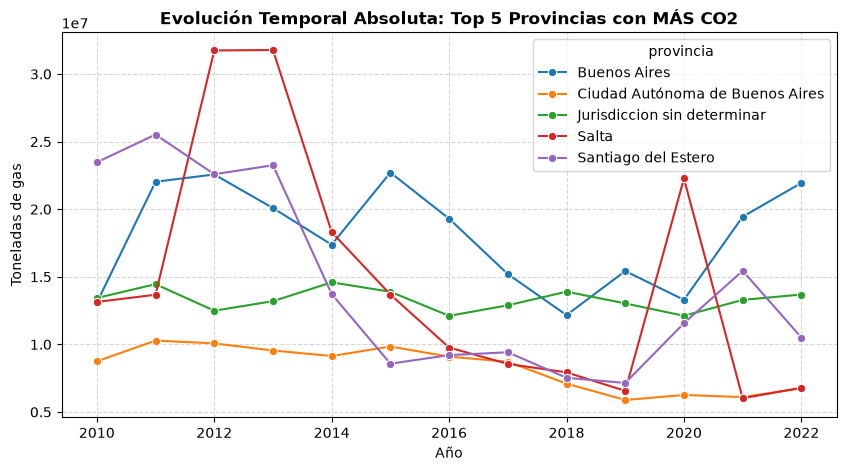

In [142]:

df_top_mas = df_grafico[df_grafico["provincia"].isin(provincias_mas)]

df_consol_mas = df_top_mas.groupby(["año", "provincia"])["valor_toneladas_gas"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_consol_mas, x="año", y="valor_toneladas_gas", hue="provincia", marker="o")
plt.title("Evolución Temporal Absoluta: Top 5 Provincias con MÁS CO2", fontsize=12, fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Toneladas de gas")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

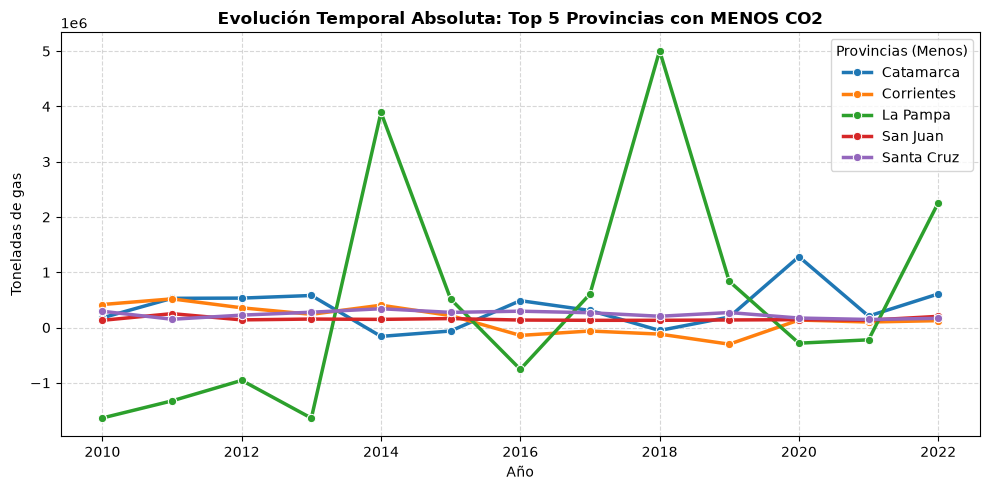

In [143]:
df_top_menos = df_grafico[df_grafico["provincia"].isin(provincias_menos)]

df_consol_menos = df_top_menos.groupby(["año", "provincia"])["valor_toneladas_gas"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_consol_menos, x="año", y="valor_toneladas_gas", hue="provincia", marker="o", linewidth=2.5)
plt.title("Evolución Temporal Absoluta: Top 5 Provincias con MENOS CO2", fontsize=12, fontweight="bold")
plt.xlabel("Año")
plt.ylabel("Toneladas de gas")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Provincias (Menos)")
plt.tight_layout()
plt.show()

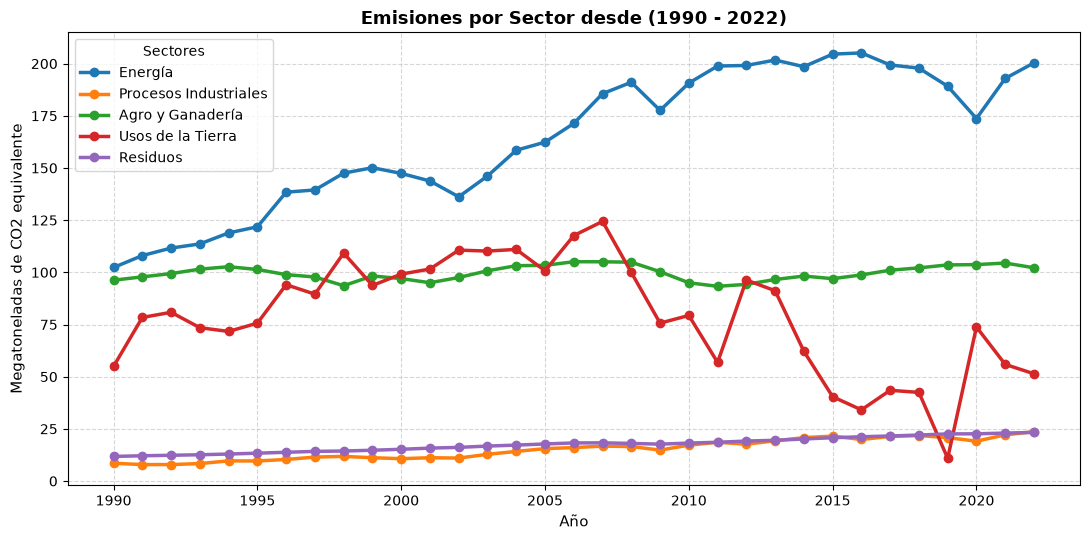

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

df_grafico_sector = df_sector.copy()
df_grafico_sector["año"] = df_grafico_sector["año"].astype(int)

df_grafico_sector = df_grafico_sector.sort_values("año")
plt.figure(figsize=(11, 5.5))

# Lineas
plt.plot(df_grafico_sector["año"], df_grafico_sector["energia"], marker="o", linewidth=2.5, label="Energía")
plt.plot(df_grafico_sector["año"], df_grafico_sector["procesos_industriales_y_uso_de_productos"], marker="o", linewidth=2.5, label="Procesos Industriales")
plt.plot(df_grafico_sector["año"], df_grafico_sector["agricultura_y_ganaderia"], marker="o", linewidth=2.5, label="Agro y Ganadería")
plt.plot(df_grafico_sector["año"], df_grafico_sector["usos_de_la_tierra_cambios_de_uso_de_la_tierra_y_silvicultura"], marker="o", linewidth=2.5, label="Usos de la Tierra")
plt.plot(df_grafico_sector["año"], df_grafico_sector["residuos"], marker="o", linewidth=2.5, label="Residuos")

# Etiquetas
plt.title("Emisiones por Sector desde (1990 - 2022)", fontsize=13, fontweight="bold")
plt.xlabel("Año", fontsize=11)
plt.ylabel("Megatoneladas de CO2 equivalente", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Leyenda
plt.legend(title="Sectores", fontsize=10)

plt.tight_layout()
plt.show()

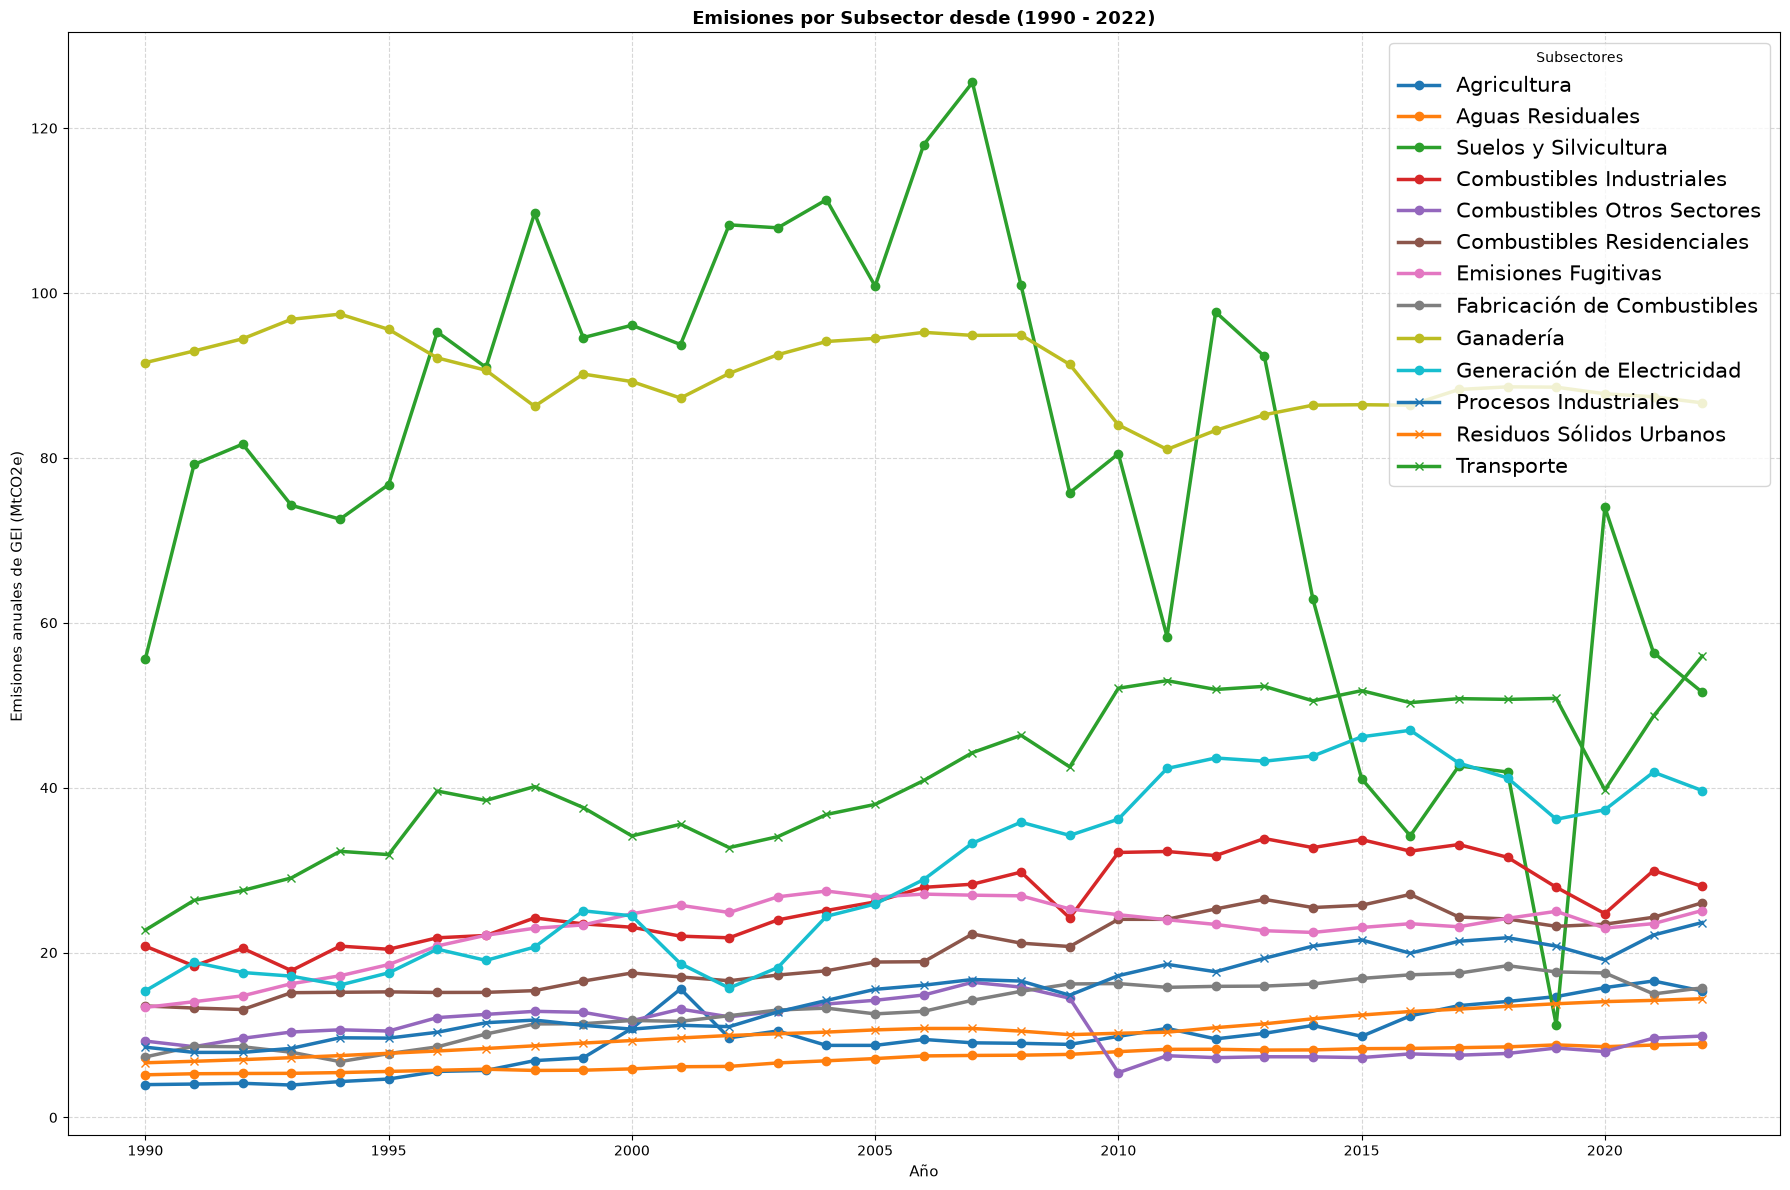

In [4]:
df_grafico_sub = df_subsector.copy()
df_grafico_sub["año"] = df_grafico_sub["año"].astype(int)

df_grafico_sub = df_grafico_sub.sort_values("año")
plt.figure(figsize=(18, 12))

# Lineas
plt.plot(df_grafico_sub["año"], df_grafico_sub["agricultura"], marker="o", linewidth=2.5, label="Agricultura")
plt.plot(df_grafico_sub["año"], df_grafico_sub["aguas_residuales"], marker="o", linewidth=2.5, label="Aguas Residuales")
plt.plot(df_grafico_sub["año"], df_grafico_sub["cambio_de_uso_de_suelos_y_silvicultura"], marker="o", linewidth=2.5, label="Suelos y Silvicultura")
plt.plot(df_grafico_sub["año"], df_grafico_sub["combustibles_industrias"], marker="o", linewidth=2.5, label="Combustibles Industriales")
plt.plot(df_grafico_sub["año"], df_grafico_sub["combustibles_otros_sectores"], marker="o", linewidth=2.5, label="Combustibles Otros Sectores")
plt.plot(df_grafico_sub["año"], df_grafico_sub["combustibles_residencial"], marker="o", linewidth=2.5, label="Combustibles Residenciales")
plt.plot(df_grafico_sub["año"], df_grafico_sub["emisiones_fugitivas"], marker="o", linewidth=2.5, label="Emisiones Fugitivas")
plt.plot(df_grafico_sub["año"], df_grafico_sub["fabricacion_de_combustibles"], marker="o", linewidth=2.5, label="Fabricación de Combustibles")
plt.plot(df_grafico_sub["año"], df_grafico_sub["ganaderia"], marker="o", linewidth=2.5, label="Ganadería")
plt.plot(df_grafico_sub["año"], df_grafico_sub["generacion_de_electricidad"], marker="o", linewidth=2.5, label="Generación de Electricidad")
plt.plot(df_grafico_sub["año"], df_grafico_sub["procesos_industriales"], marker="x", linewidth=2.5, label="Procesos Industriales")
plt.plot(df_grafico_sub["año"], df_grafico_sub["residuos_solidos_urbanos"], marker="x", linewidth=2.5, label="Residuos Sólidos Urbanos")
plt.plot(df_grafico_sub["año"], df_grafico_sub["transporte"], marker="x", linewidth=2.5, label="Transporte")

# Etiquetas
plt.title("Emisiones por Subsector desde (1990 - 2022)", fontsize=13, fontweight="bold")
plt.xlabel("Año", fontsize=11)
plt.ylabel("Emisiones anuales de GEI (MtCO2e) ", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.5)

# Leyenda
plt.legend(title="Subsectores", fontsize=15)

plt.tight_layout()
plt.show()

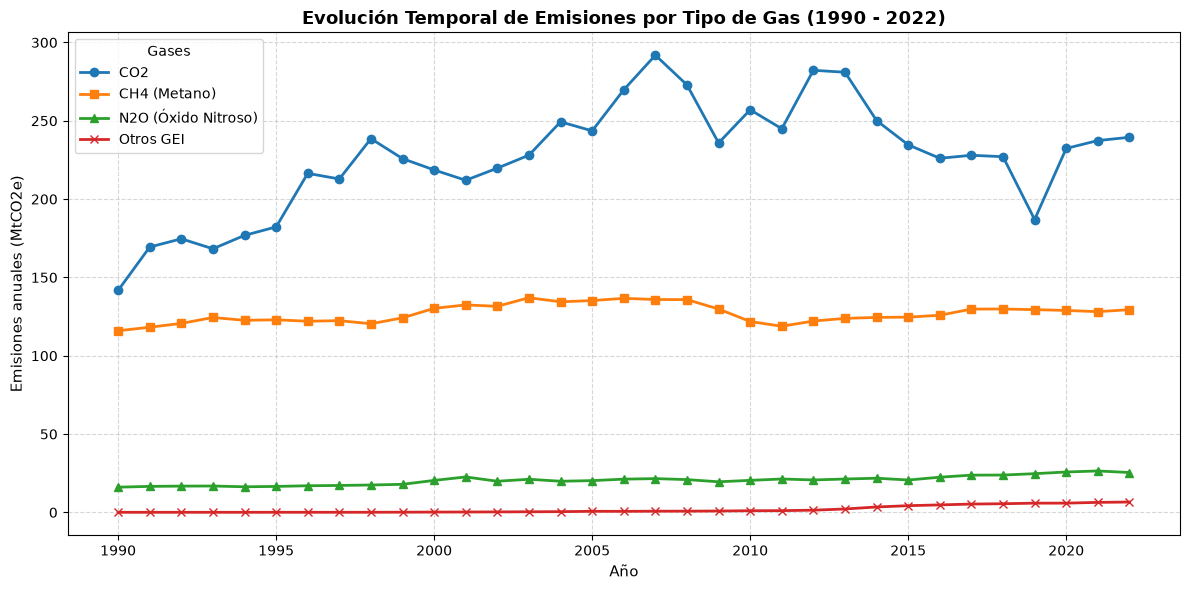

In [ ]:

df_grafico = df_gas.copy()
df_grafico["año"] = df_grafico["año"].astype(int)

df_filtrado = df_grafico[(df_grafico["año"] >= 1990) & (df_grafico["año"] <= 2022)]
df_filtrado = df_filtrado.sort_values("año")


plt.figure(figsize=(12, 6))

plt.plot(df_filtrado["año"], df_filtrado["co2"], marker="o", linewidth=2, label="CO2")
plt.plot(df_filtrado["año"], df_filtrado["ch4"], marker="s", linewidth=2, label="CH4 (Metano)")
plt.plot(df_filtrado["año"], df_filtrado["n2o"], marker="^", linewidth=2, label="N2O (Óxido Nitroso)")
plt.plot(df_filtrado["año"], df_filtrado["otros_gei"], marker="x", linewidth=2, label="Otros GEI")


plt.title("Evolución Temporal de Emisiones por Tipo de Gas (1990 - 2022)", fontsize=13, fontweight="bold")
plt.xlabel("Año", fontsize=11)

unidad = df_filtrado['unidad_de_medida'].iloc[0] if 'unidad_de_medida' in df_filtrado.columns else "Toneladas"
plt.ylabel(f"Emisiones anuales ({unidad})", fontsize=11)

plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Gases", fontsize=10)

plt.tight_layout()
plt.show()